--- INICIANDO SCRIPT CUANTITATIVO (@alphametricsve) ---

[Fase 1 y 2] Extrayendo y formateando series temporales...
-> Éxito. Datos estructurados. Registros iniciales: 10092
-> Éxito. Muestra conglomerada en 577 velas horarias.

[Fase 3 y 4] Aplicando filtro de tendencia (Detrending)...

[Fase 5 y 6] Generando Matriz de Calor estacional...


C:\Users\willb\AppData\Local\Temp\ipykernel_13420\3692609527.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['precio_mediana'].resample('H').median().dropna().to_frame(name='mediana')


-> Éxito. Visualización exportada a alta resolución en: .\mapa_calor_compraventa_usdt.png

================ REPORTE QUANT DIARIO ================
--- LUNES ---
  COMPRA (ZONA VERDE): 07:00 | Desviación Mediana: -0.678%
  VENTA  (ZONA ROJA) : 18:00 | Desviación Mediana: 1.002%
--- MARTES ---
  COMPRA (ZONA VERDE): 08:00 | Desviación Mediana: -1.310%
  VENTA  (ZONA ROJA) : 00:00 | Desviación Mediana: 0.632%
--- MIÉRCOLES ---
  COMPRA (ZONA VERDE): 07:00 | Desviación Mediana: -0.798%
  VENTA  (ZONA ROJA) : 17:00 | Desviación Mediana: 0.331%
--- JUEVES ---
  COMPRA (ZONA VERDE): 10:00 | Desviación Mediana: -0.292%
  VENTA  (ZONA ROJA) : 18:00 | Desviación Mediana: 0.284%
--- VIERNES ---
  COMPRA (ZONA VERDE): 13:00 | Desviación Mediana: -0.699%
  VENTA  (ZONA ROJA) : 04:00 | Desviación Mediana: 0.268%
--- SÁBADO ---
  COMPRA (ZONA VERDE): 19:00 | Desviación Mediana: -0.290%
  VENTA  (ZONA ROJA) : 04:00 | Desviación Mediana: 0.292%
--- DOMINGO ---
  COMPRA (ZONA VERDE): 19:00 | Desviación M

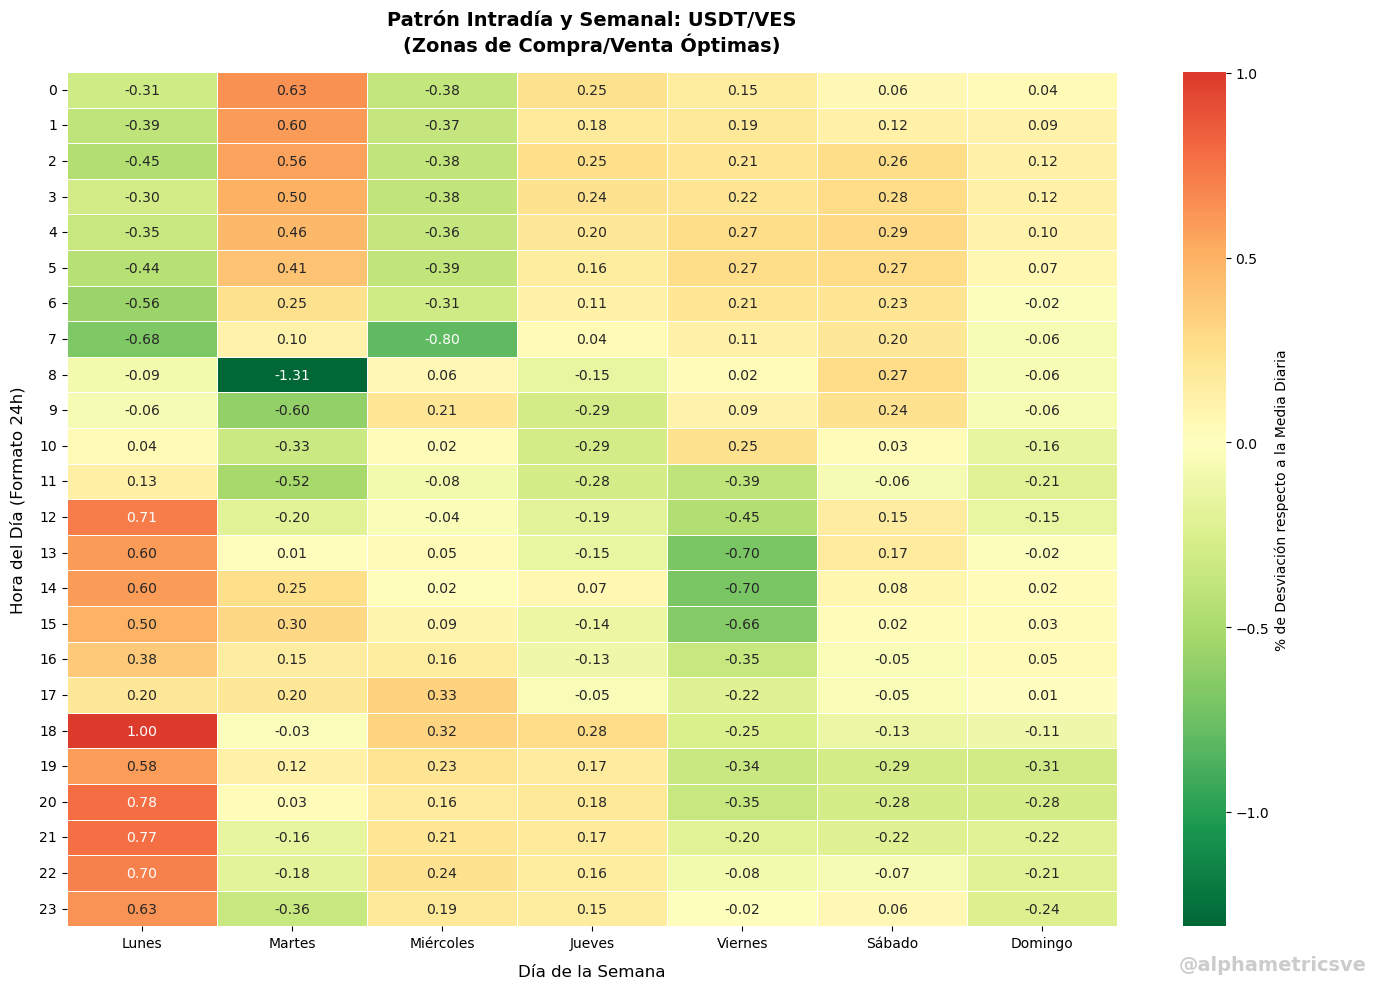

In [2]:
"""
Proyecto: Microestructura de mercado intradía (USDT/VES)
Autor: @alphametricsve (Seudónimo Profesional)
Descripción: Identificación de ventanas horarias óptimas de compra y venta 
             mediante técnicas de detrending (rolling mean) y análisis estacional.
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO SCRIPT CUANTITATIVO (@alphametricsve) ---")

# --- CONFIGURACIÓN DE RUTAS RELATIVAS ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else '.'
INPUT_FILE = os.path.join(BASE_DIR, "historico_p2p_usdt_ves.csv")
OUTPUT_IMAGE = os.path.join(BASE_DIR, "mapa_calor_compraventa_usdt.png")

# --- FASE 1 Y 2: EXTRACCIÓN Y LIMPIEZA ---
try:
    print("\n[Fase 1 y 2] Extrayendo y formateando series temporales...")
    df = pd.read_csv(INPUT_FILE)
    df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])
    df['precio_mediana'] = pd.to_numeric(df['precio_mediana'], errors='coerce')
    df.set_index('fecha_hora', inplace=True)
    print(f"-> Éxito. Datos estructurados. Registros iniciales: {df.shape[0]}")
except Exception as e:
    print(f"-> [ERROR COMPILACIÓN] Verifique que '{os.path.basename(INPUT_FILE)}' esté en el mismo directorio. Detalle: {e}")
    exit()

# --- FASE 3: CONGLOMERACIÓN (RESAMPLING A 1 HORA) ---
df_hourly = df['precio_mediana'].resample('H').median().dropna().to_frame(name='mediana')
print(f"-> Éxito. Muestra conglomerada en {df_hourly.shape[0]} velas horarias.")

# --- FASE 4: MODELO ECONOMÉTRICO (DETRENDING) ---
print("\n[Fase 3 y 4] Aplicando filtro de tendencia (Detrending)...")
# Media móvil centrada de 24 horas para aislar la tendencia macrocambiaria
df_hourly['rolling_mean_24h'] = df_hourly['mediana'].rolling(window=24, center=True).mean()
df_hourly['deviation_pct'] = ((df_hourly['mediana'] - df_hourly['rolling_mean_24h']) / df_hourly['rolling_mean_24h']) * 100

# Extracción de componentes estacionales de la serie temporal
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly.dropna(inplace=True)

# --- FASE 5: PREPARACIÓN DE MATRIZ ESTACIONAL ---
days_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
heatmap_data = df_hourly.pivot_table(values='deviation_pct', index='hour', columns='day_of_week', aggfunc='mean')
heatmap_data.columns = [days_map[c] for c in heatmap_data.columns]

# --- FASE 6: RENDERIZADO VISUAL ---
print("\n[Fase 5 y 6] Generando Matriz de Calor estacional...")
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data, annot=True, cmap='RdYlGn_r', fmt=".2f", center=0, 
    cbar_kws={'label': '% de Desviación respecto a la Media Diaria'}, linewidths=.5
)

plt.title('Patrón Intradía y Semanal: USDT/VES\n(Zonas de Compra/Venta Óptimas)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Día de la Semana', fontsize=12, labelpad=10)
plt.ylabel('Hora del Día (Formato 24h)', fontsize=12, labelpad=10)
plt.yticks(rotation=0)

# Firma y Marca de Agua
plt.figtext(0.98, 0.02, '@alphametricsve', fontsize=14, color='gray', fontweight='bold', ha='right', va='bottom', alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300)
print(f"-> Éxito. Visualización exportada a alta resolución en: {OUTPUT_IMAGE}")

# --- FASE 7: EXTRACCIÓN DE ALPHAS OPERATIVOS ---
print("\n================ REPORTE QUANT DIARIO ================")
mean_by_hour_day = df_hourly.groupby(['day_of_week', 'hour'])['deviation_pct'].mean().reset_index()

for day_idx, day_name in days_map.items():
    day_data = mean_by_hour_day[mean_by_hour_day['day_of_week'] == day_idx]
    if day_data.empty: continue
    
    cheapest = day_data.loc[day_data['deviation_pct'].idxmin()]
    most_expensive = day_data.loc[day_data['deviation_pct'].idxmax()]
    
    print(f"--- {day_name.upper()} ---")
    print(f"  COMPRA (ZONA VERDE): {int(cheapest['hour']):02d}:00 | Desviación Mediana: {cheapest['deviation_pct']:.3f}%")
    print(f"  VENTA  (ZONA ROJA) : {int(most_expensive['hour']):02d}:00 | Desviación Mediana: {most_expensive['deviation_pct']:.3f}%")

print("======================================================\n")